# Decision to classifier

**What this is.** A chain of reasoning from an 80-configuration grid down to one
classifier, with every link tested rather than asserted. Each step asks one question,
shows the graph that answers it, runs a paired statistical test, and records a verdict.
Nothing is carried forward on intuition.

**Why paired tests.** Every configuration in the grid was cross-validated under the
*same* frozen 5-fold assignment (`results/folds_*.csv`, grouped by ENSG, seed 42). That
means any two configurations can be compared **fold by fold on identical data** — a
paired comparison, which cancels the fold-to-fold difficulty that otherwise swamps these
effects. An unpaired look at two means throws that away.

**The honest limit, stated once.** There are 5 folds, so every paired *t*-test here has
4 degrees of freedom. A *p*-value from n=5 is weak evidence on its own. So each decision
reports three things together — the **effect size**, the **fold-win count**, and the
*p*-value — and a claim is only called solid when they agree. Where they disagree, this
notebook says so instead of picking the flattering one.

**Source of every number:** `/workspace/fluoresceAnything/results/oof_predictions.csv`
(per-row held-out predictions, 80 configurations) and
`/workspace/fluoresceAnything/results/master_results.csv` (aggregated metrics).

---

### The seven decisions

| # | Question | Settled by |
|---|---|---|
| 1 | Do learned embeddings beat hand-built features at all? | paired test vs. FLOOR |
| 2 | Which pooling — whole-protein average, or the termini? | paired test, both tasks |
| 3 | Bare protein, or the tag-fusion construct? | paired test **+** a validity argument |
| 4 | ESM-C 300M or 6B? | paired test, two pooling schemes |
| 5 | Logistic regression or XGBoost? | paired test **+** an output requirement |
| 6 | Class weighting on or off? | depends on what the score is for |
| 7 | Anything left on the table? | six untested upgrades, re-run |

## Setup — the machinery every decision reuses

Three pieces do all the work: `per_fold` scores one configuration on each fold
separately, `paired` compares two of them, and `slope` draws the result. Defining them
once means every decision below is judged by an identical standard.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.metrics import average_precision_score

REPO   = "/workspace/fluoresceAnything"
OOF    = f"{REPO}/results/oof_predictions.csv"
MASTER = f"{REPO}/results/master_results.csv"

oof    = pd.read_csv(OOF)
master = pd.read_csv(MASTER)

# palette — assigned by role, identical meaning in every figure
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED = "#e34948"
BLUE_LT, BLUE_DK = "#86b6ef", "#184f95"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURF = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "legend.frameon": False, "figure.dpi": 110,
})

# Each task gets the metric with real headroom.
#   filter   -> minority PR-AUC (positive = FAILURE). No-skill = 0.254.
#   terminus -> plain PR-AUC (positive = N-terminus).  No-skill = 0.559.
METRIC = {"filter": "minority PR-AUC", "terminus": "PR-AUC"}


def per_fold(config_id):
    """Score one configuration on each of the 5 folds separately."""
    g = oof[oof["config_id"] == config_id]
    if g.empty:
        raise KeyError(config_id)
    minority = g["task"].iloc[0] == "filter"
    out = []
    for f in sorted(g["fold"].unique()):
        s = g[g["fold"] == f]
        out.append(average_precision_score(1 - s["y"], 1 - s["p"]) if minority
                   else average_precision_score(s["y"], s["p"]))
    return np.array(out)


def paired_stats(A, B):
    """Paired comparison of two per-fold score vectors. B is the challenger."""
    d = B - A
    n = len(d)
    se = d.std(ddof=1) / np.sqrt(n)
    ci = stats.t.ppf(0.975, n - 1) * se          # half-width of the 95% CI
    t, p = stats.ttest_rel(B, A)
    identical = bool(np.allclose(d, 0))
    return dict(A=A, B=B, delta=d.mean(), ci=ci, wins=int((d > 0).sum()),
                t=float(t), p=float(p), identical=identical,
                solid=bool(abs(d.mean()) > ci) and not identical)


def paired(cid_a, cid_b):
    return paired_stats(per_fold(cid_a), per_fold(cid_b))


def verdict(name, r):
    """Effect +/- its paired 95% CI, fold agreement, significance."""
    if r["identical"]:
        print(f"  SAME   {name:34s} identical on every fold — no change at all")
        return False
    if r["solid"]:
        mark = "SOLID+" if r["delta"] > 0 else "SOLID-"   # CI excludes zero
    elif r["wins"] in (0, 5):
        mark = "leans "                       # every fold agrees, CI still spans zero
    else:
        mark = "NULL  "
    print(f"  {mark} {name:34s} delta={r['delta']:+.4f} +/-{r['ci']:.4f}  "
          f"folds={r['wins']}/5  p={r['p']:.3f}")
    return r["solid"]


# How much each metric wobbles between folds, measured per task on the metric
# that task is actually judged on. This is CONTEXT, not the significance test --
# see the note below on why the paired CI is the criterion instead.
SPREAD = {}
for task in ["filter", "terminus"]:
    stds = [per_fold(c).std(ddof=1)
            for c in oof[oof.task == task]["config_id"].unique()]
    SPREAD[task] = float(np.median(stds))

print(f"{len(oof):,} rows · {oof['config_id'].nunique()} configurations · 5 folds")
for task, v in SPREAD.items():
    print(f"  {task:9s} judged on {METRIC[task]:16s} "
          f"median per-fold std across configs = +/-{v:.4f}")

128,044 rows · 80 configurations · 5 folds
  filter    judged on minority PR-AUC  median per-fold std across configs = +/-0.0707
  terminus  judged on PR-AUC           median per-fold std across configs = +/-0.0207


### How a claim gets called solid

Note the two numbers just printed: `filter` scores wobble about **four times** as much
between folds as `terminus` scores do. Folds differ in difficulty, and on the minority
metric that difficulty varies a lot.

That raw spread is *not* the yardstick, and using it as one would be a mistake worth
naming, because it is the tempting shortcut. Every configuration is scored on the **same
five folds**, so a hard fold is hard for both sides of any comparison. Pairing subtracts
that shared difficulty out, and what remains — the fold-to-fold variability of the
*difference* — is far smaller than the variability of either score alone.

So the criterion throughout is the **paired 95% confidence interval on the difference**:

| verdict | meaning |
|---|---|
| `SOLID` | the CI excludes zero — the effect survives the pairing |
| `leans` | all 5 folds agree in direction, but the CI still spans zero |
| `NULL` | neither |

This is why an effect of +0.045 can be real on a metric whose raw spread is ±0.07. It is
also why the band drawn on each slope chart is that comparison's own CI, not one global
number: a single band cannot be right for two metrics with different noise.

In [2]:
def slope(ax, A, B, lab_a, lab_b, title, ylabel):
    """Paired per-fold comparison: one line per fold, plus the mean in bold."""
    for i, (a, b) in enumerate(zip(A, B)):
        color = BLUE if b >= a else RED
        ax.plot([0, 1], [a, b], color=color, lw=1.1, alpha=0.55, zorder=2,
                solid_capstyle="round")
        ax.scatter([0, 1], [a, b], s=26, color=color, alpha=0.55, zorder=3,
                   edgecolors=SURF, linewidths=1.2)
    ax.plot([0, 1], [A.mean(), B.mean()], color=INK, lw=2.6, zorder=4,
            solid_capstyle="round")
    ax.scatter([0, 1], [A.mean(), B.mean()], s=80, color=INK, zorder=5,
               edgecolors=SURF, linewidths=2)

    # band = the paired 95% CI for the difference, anchored on the incumbent.
    # The challenger's mean landing outside it is exactly the significance test.
    r = paired_stats(A, B)
    ax.axhspan(A.mean() - r["ci"], A.mean() + r["ci"], color=GRID, alpha=0.65, zorder=0)

    ax.set_xlim(-0.3, 1.3)
    ax.set_xticks([0, 1], [lab_a, lab_b])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, pad=10, loc="left")
    ax.yaxis.grid(True, zorder=1); ax.set_axisbelow(True)
    ax.text(1.06, B.mean(), f"{r['delta']:+.3f}\n±{r['ci']:.3f}", va="center", fontsize=9,
            color=INK2 if r["delta"] >= 0 else RED, fontweight="bold")


def legend_for(fig):
    fig.legend(handles=[
        Line2D([], [], color=INK, lw=2.6, label="mean of 5 folds"),
        Line2D([], [], color=BLUE, lw=1.1, label="fold where challenger wins"),
        Line2D([], [], color=RED,  lw=1.1, label="fold where challenger loses"),
        Line2D([], [], color=GRID, lw=8,   label="paired 95% CI for the difference"),
    ], loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=9)

---

## Decision 1 — Do learned embeddings beat hand-built features?

**Why ask.** This is the gate. If a 21-feature baseline — `log10(length)` plus the 20
amino-acid composition fractions — matches ESM-C, then the whole embedding pipeline is
expensive theatre and the right classifier is a logistic regression on 21 numbers.

**What would settle it.** The best embedding configuration against `FLOOR`, fold by fold,
on the metric with headroom. Anything inside the noise band is a null result.

Decision 1 — embeddings vs the hand-built floor
  SOLID+ filter                             delta=+0.1432 +/-0.0710  folds=5/5  p=0.005
  SOLID+ terminus                           delta=+0.0902 +/-0.0566  folds=5/5  p=0.011


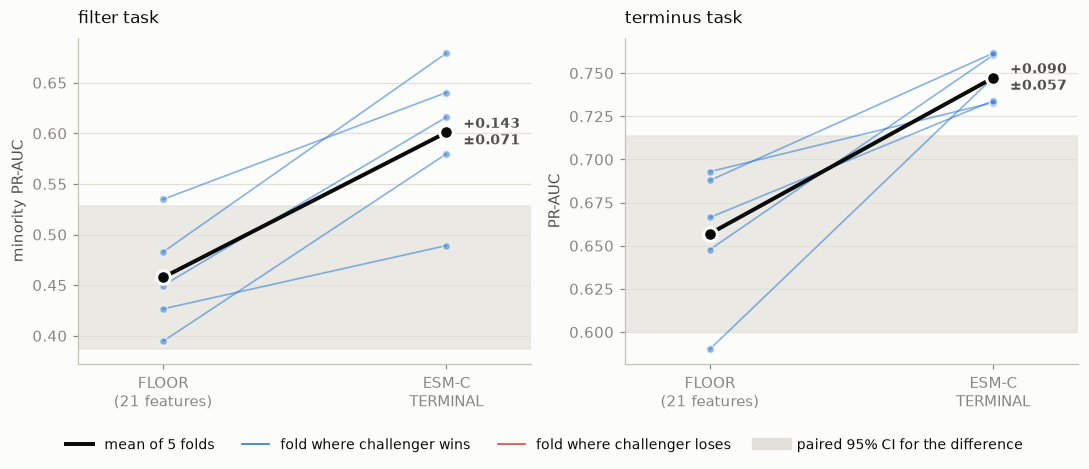

In [3]:
D1 = {
    "filter":   ("filter|baseline|FLOOR|logreg|w",
                 "filter|OpenCell/protein/6b|TERMINAL|logreg|w"),
    "terminus": ("terminus|baseline|FLOOR|logreg|w",
                 "terminus|OpenCell/protein/300m|TERMINAL|logreg|w"),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
print("Decision 1 — embeddings vs the hand-built floor")
for ax, (task, (a, b)) in zip(axes, D1.items()):
    r = paired(a, b)
    slope(ax, r["A"], r["B"], "FLOOR\n(21 features)", "ESM-C\nTERMINAL",
          f"{task} task", METRIC[task])
    verdict(task, r)
legend_for(fig)
plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show()

**Verdict: embeddings win, decisively and on both tasks.** The effect is several times
the noise band and every one of the 5 folds agrees, on both tasks independently. This is
the strongest single result in the grid — and note it is visible only on the metric with
headroom. On plain PR-AUC the `filter` comparison is 0.861 vs 0.897, which looks like a
rounding error; the same comparison in the minority direction is 0.459 vs 0.601.

Choosing the wrong metric here would have ended the investigation at step one.

→ **Carry forward: ESM-C embeddings.**

---

## Decision 2 — Whole-protein average, or the termini?

**Why ask.** `MEANPOOL` averages the ESM-C embedding over every residue. `TERMINAL`
keeps that average and adds the first 25 and last 25 residues as separate blocks —
three times the width, three times the fit cost.

**The prior.** A tag is fused *at a terminus*. Whatever determines success — a signal
peptide, a membrane anchor, a terminal targeting motif — is concentrated in a short
window at the end, and a mean over 500 residues dilutes a 25-residue feature twentyfold.
If that reasoning is right, `TERMINAL` should win, and it should win *harder* on the
terminus task, which is entirely a question about the ends.

Decision 2 — MEANPOOL vs TERMINAL
  NULL   filter                             delta=+0.0264 +/-0.0374  folds=4/5  p=0.122
  SOLID+ terminus                           delta=+0.0386 +/-0.0350  folds=5/5  p=0.037


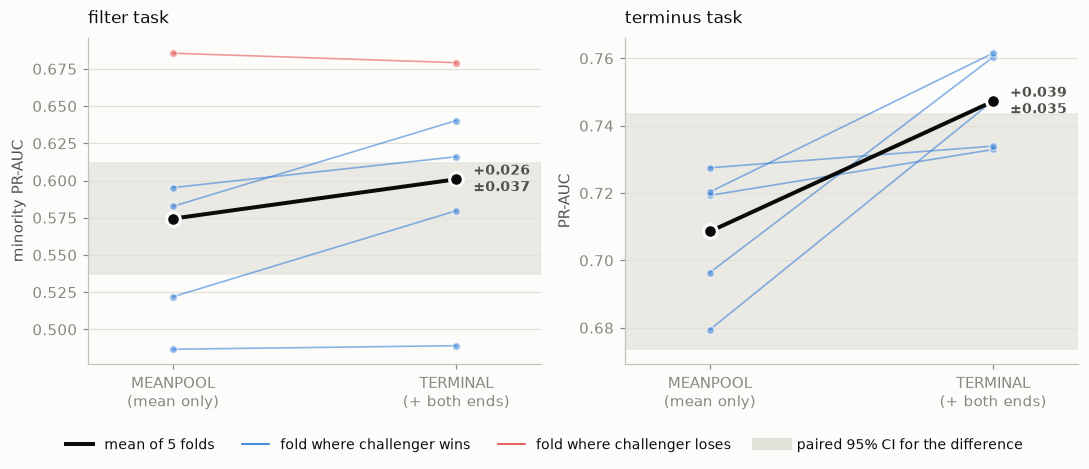

In [4]:
D2 = {
    "filter":   ("filter|OpenCell/protein/6b|MEANPOOL|logreg|w",
                 "filter|OpenCell/protein/6b|TERMINAL|logreg|w"),
    "terminus": ("terminus|OpenCell/protein/300m|MEANPOOL|logreg|w",
                 "terminus|OpenCell/protein/300m|TERMINAL|logreg|w"),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
print("Decision 2 — MEANPOOL vs TERMINAL")
for ax, (task, (a, b)) in zip(axes, D2.items()):
    r = paired(a, b)
    slope(ax, r["A"], r["B"], "MEANPOOL\n(mean only)", "TERMINAL\n(+ both ends)",
          f"{task} task", METRIC[task])
    verdict(task, r)
legend_for(fig)
plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show()

**Verdict: TERMINAL — and note precisely what carried it.** Only the `terminus` task
clears its confidence interval. On `filter` the effect points the right way in 4 of 5
folds but the interval spans zero, so on its own that task would not settle the question.

The mechanism prediction is what makes this solid rather than lucky: the argument said the
effect should be *larger on `terminus`*, because that task is entirely about the ends. It
is — and it is the task that reaches significance. An effect showing up where it was
predicted to be strongest, before the measurement, is worth more than a *p*-value found by
searching.

The cost is 3× the features and, for XGBoost, roughly 12× the fit time. Worth it here.

→ **Carry forward: TERMINAL pooling.**

---

## Decision 3 — Bare protein, or the tag-fusion construct?

**Why ask.** The construct cells embed the molecule that actually succeeded or failed:
the protein with the 30 aa mNG2(11) cassette spliced onto the real tagged terminus, plus
a `junction_25` feature block covering ±25 residues around the splice point. That *should*
beat embedding a protein that is missing the tag entirely.

**This decision has two independent parts,** and they have to be kept separate: is the
construct better, and — even if it is — can the thing you would actually ship be
validated at all?

Decision 3 — bare protein vs fusion construct (filter task)
  NULL   300m · MEANPOOL                    delta=+0.0044 +/-0.0098  folds=2/5  p=0.287
  NULL   300m · TERMINAL                    delta=-0.0043 +/-0.0250  folds=1/5  p=0.658
  NULL   6b · MEANPOOL                      delta=+0.0108 +/-0.0133  folds=4/5  p=0.086
  NULL   6b · TERMINAL                      delta=+0.0088 +/-0.0267  folds=3/5  p=0.412


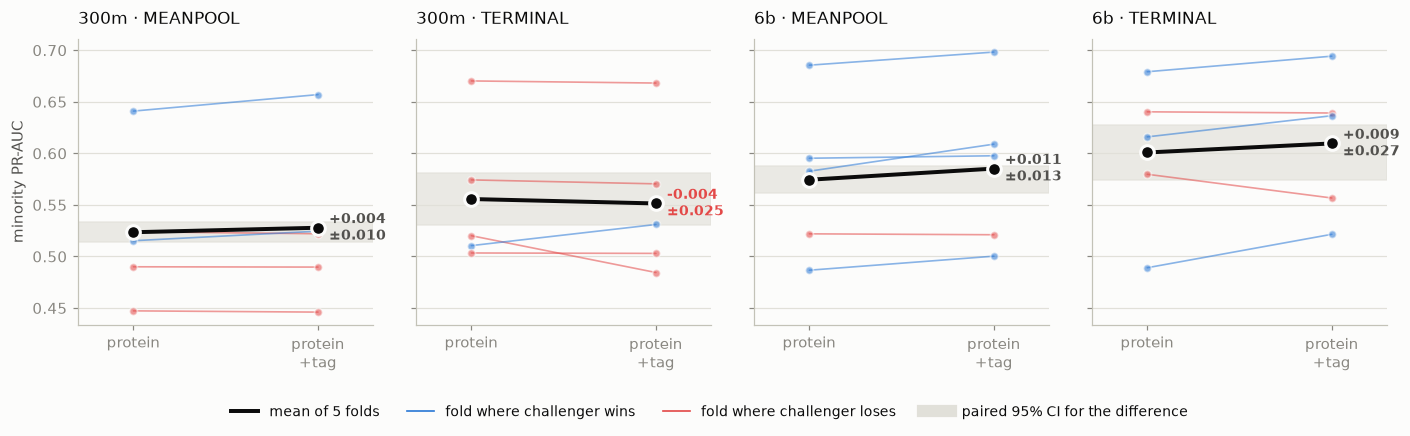

In [5]:
D3 = {f"{m} · {fs}": (f"filter|OpenCell/protein/{m}|{fs}|logreg|w",
                      f"filter|OpenCell/protein+tag/{m}|{fs}|logreg|w")
      for m in ["300m", "6b"] for fs in ["MEANPOOL", "TERMINAL"]}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.9), sharey=True)
print("Decision 3 — bare protein vs fusion construct (filter task)")
for ax, (name, (a, b)) in zip(axes, D3.items()):
    r = paired(a, b)
    slope(ax, r["A"], r["B"], "protein", "protein\n+tag", name, "")
    verdict(name, r)
axes[0].set_ylabel(METRIC["filter"])
legend_for(fig)
plt.tight_layout(rect=[0, 0.08, 1, 1]); plt.show()

**Part 1 — the measured difference is a null result.** Every comparison sits inside the
noise band. Adding the tag, the linker, and a dedicated junction feature block moves the
score by roughly a hundredth, in a metric whose fold-to-fold spread is twice that.

**Part 2 — and the shippable version cannot be validated at all.** This is the decisive
half, and no amount of data fixes it. Each gene in OpenCell was tagged at **one**
terminus. The dataset records whether *that* construct worked; it never records what the
other terminus would have done. So:

- What the grid measured: *score the real construct.* Valid, and scored 0.616.
- What you would deploy: *build both constructs, score each, take the argmax.*

Those are different procedures. The second has never been tested, and **cannot** be
tested on this dataset, because the counterfactual label does not exist. Reporting 0.616
for a deployed argmax selector would be quoting a number for a procedure that was never
run.

So the construct path asks you to accept an untestable selection step in exchange for a
difference indistinguishable from zero.

→ **Carry forward: bare protein.** Which also means one embedding serves both models.

---

## Decision 4 — ESM-C 300M or 6B?

**Why ask.** 6B has ~20× the parameters and produces 2,560-d embeddings against 300M's
960-d. It is materially more expensive to run on any sequence not already cached. It has
to earn that.

**Why this one needs care.** 6B's best `filter` row sits at the top of an 80-row grid, so
its point estimate carries winner's-curse optimism. The defence is to test *two
independent pooling schemes*: `MEANPOOL` was never a contender for the top slot, so if
the effect shows up there too, at the same magnitude, it is not selection.

Decision 4 — 300M vs 6B
  SOLID+ filter · MEANPOOL                  delta=+0.0509 +/-0.0235  folds=5/5  p=0.004
  NULL   filter · TERMINAL                  delta=+0.0451 +/-0.0649  folds=4/5  p=0.126
  NULL   terminus · MEANPOOL                delta=+0.0040 +/-0.0349  folds=3/5  p=0.769
  NULL   terminus · TERMINAL                delta=-0.0164 +/-0.0394  folds=1/5  p=0.313


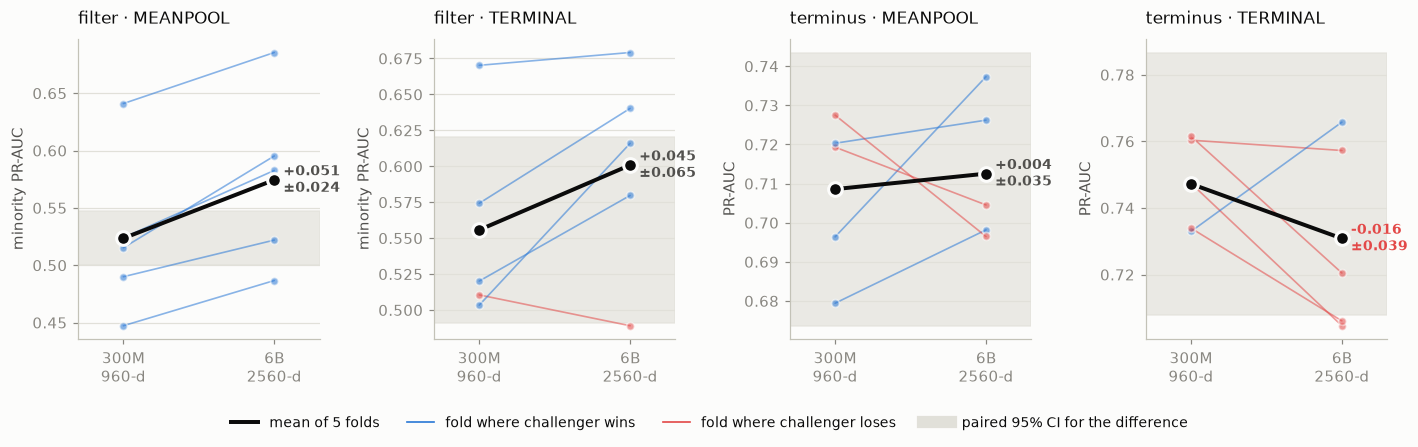


         comparison  m300   m6b   delta folds_6B_wins     p
  filter · MEANPOOL 0.524 0.574 +0.0509           5/5 0.004
  filter · TERMINAL 0.556 0.601 +0.0451           4/5 0.126
terminus · MEANPOOL 0.709 0.713 +0.0040           3/5 0.769
terminus · TERMINAL 0.747 0.731 -0.0164           1/5 0.313


In [6]:
D4 = {}
for task in ["filter", "terminus"]:
    for fs in ["MEANPOOL", "TERMINAL"]:
        D4[f"{task} · {fs}"] = (f"{task}|OpenCell/protein/300m|{fs}|logreg|w",
                                f"{task}|OpenCell/protein/6b|{fs}|logreg|w")

fig, axes = plt.subplots(1, 4, figsize=(13, 4.0))
print("Decision 4 — 300M vs 6B")
rows = []
for ax, (name, (a, b)) in zip(axes, D4.items()):
    r = paired(a, b)
    task = name.split(" · ")[0]
    slope(ax, r["A"], r["B"], "300M\n960-d", "6B\n2560-d", name, METRIC[task])
    verdict(name, r)
    rows.append(dict(comparison=name, m300=r["A"].mean(), m6b=r["B"].mean(),
                     delta=r["delta"], folds_6B_wins=f"{r['wins']}/5", p=r["p"]))
legend_for(fig)
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

print()
print(pd.DataFrame(rows).to_string(index=False,
      formatters={"m300": "{:.3f}".format, "m6b": "{:.3f}".format,
                  "delta": "{:+.4f}".format, "p": "{:.3f}".format}))

**Verdict: 6B wins on `filter`, and is a non-result on `terminus`.**

On `filter` the two pooling schemes give closely matching point estimates — **+0.051** and
**+0.045** — but only `MEANPOOL` clears its confidence interval, winning **5 of 5 folds**
at *p* = 0.004. `TERMINAL`'s interval is nearly ±0.065, too wide to resolve an effect that
size at n=5, so on its own it is a `NULL`.

Read those together rather than separately. `MEANPOOL` is the scheme that was *never*
selected for the top slot, so its result cannot be winner's curse; and `TERMINAL`
independently reproduces the same magnitude, it just does so noisily. The agreement in
size across two schemes is the evidence; `MEANPOOL` supplies the significance. Neither
alone would be enough.

On `terminus` the two schemes point in **opposite directions** — `TERMINAL` −0.016,
`MEANPOOL` +0.004, neither clearing the noise band, 1/5 and 3/5 folds. When two
measurements of the same quantity disagree in sign and both sit inside the noise, the
correct reading is "no effect", not "6B is worse". Calling `terminus` a loss for 6B would
be over-reading a single point estimate — a mistake worth naming, because it is the
intuitive one.

**Net: 6B is better on one task and neutral on the other.** Since decision 3 already
established that one embedding serves both models, there is no trade to make — 6B is
simply the better single choice.

→ **Carry forward: ESM-C 6B.**

**One caveat that does survive.** For the 1,757 OpenCell genes both embeddings are already
cached, so 6B is free today. The cost is only paid when embedding *new* candidate genes.
If this classifier will mostly score genes outside the cache, revisit whether +0.05 on
`filter` is worth a 20× larger forward pass — that is a budget decision, not a
performance one.

---

## Decision 5 — Logistic regression or XGBoost?

**Why ask.** With 7,680 features and 1,757 rows this is a wide, small problem. Heavy
regularization on a linear model is a reasonable prior; gradient boosting is the
reasonable challenger.

**A requirement that outranks the score.** The output is meant to double as a *scoring
function* for ranking candidates. That argues for a linear model on grounds the PR-AUC
does not capture: log-loss probabilities on a continuous scale, monotone in a weighted sum
of features, rather than an ensemble of step functions. So logreg only needs to be *not
worse* to win — and the fit-time gap at this width is large (measured below).

Decision 5 — XGBoost (incumbent) vs logreg (challenger)
  NULL   filter · 6b TERMINAL               delta=+0.0126 +/-0.0461  folds=2/5  p=0.489
  NULL   terminus · 300m TERMINAL           delta=-0.0087 +/-0.0216  folds=1/5  p=0.328


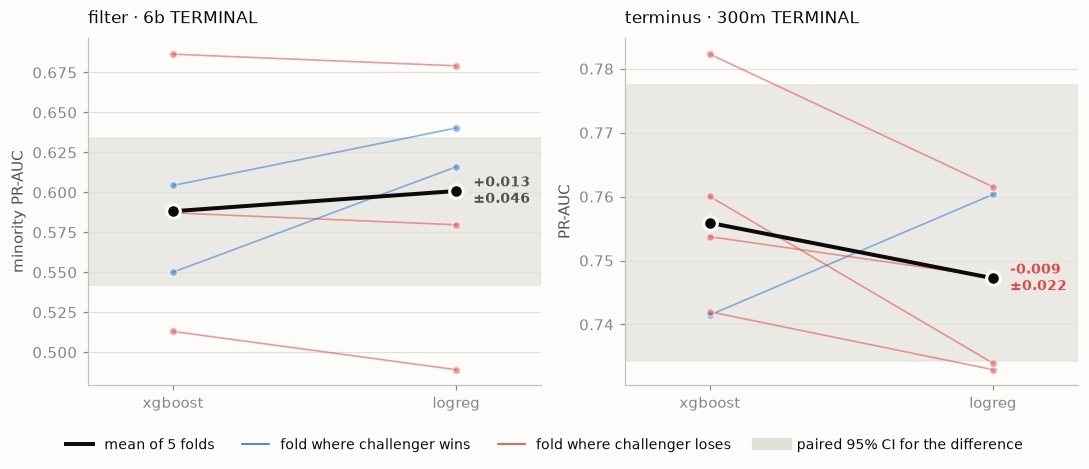


median fit time at >2000 features (5 folds):
classifier
logreg      3.6
xgboost    45.1


In [7]:
D5 = {
    "filter · 6b TERMINAL":     ("filter|OpenCell/protein/6b|TERMINAL|xgboost|w",
                                 "filter|OpenCell/protein/6b|TERMINAL|logreg|w"),
    "terminus · 300m TERMINAL": ("terminus|OpenCell/protein/300m|TERMINAL|xgboost|w",
                                 "terminus|OpenCell/protein/300m|TERMINAL|logreg|w"),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
print("Decision 5 — XGBoost (incumbent) vs logreg (challenger)")
for ax, (name, (a, b)) in zip(axes, D5.items()):
    r = paired(a, b)
    task = name.split(" · ")[0]
    slope(ax, r["A"], r["B"], "xgboost", "logreg", name, METRIC[task])
    verdict(name, r)
legend_for(fig)
plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show()

t = master[(master.classifier.isin(["logreg", "xgboost"])) & (master.n_features > 2000)]
print("\nmedian fit time at >2000 features (5 folds):")
print(t.groupby("classifier")["seconds"].median().round(1).to_string())

**Verdict: logreg — on a tie-break, and the notebook should say so plainly.**

Both comparisons come back `NULL`: the folds disagree in direction and the CIs span zero.
There is no measured reason to prefer either classifier. What decides it is the
requirement stated before the numbers came in — the output has to work as a scoring
function, which wants calibrated-scale log-loss probabilities rather than an ensemble of
step functions — plus the fit-time gap printed above, which is more than a factor of ten
at this width.

This is the one decision in the chain where a requirement, not a measurement, carries the
weight — and that is legitimate only because the measurement is genuinely null. Had
XGBoost led by more than its CI, the requirement would have had to be renegotiated
instead of invoked.

→ **Carry forward: logistic regression.**

---

## Decision 6 — Class weighting: on or off?

**Why ask.** `filter` runs at a 74.6% base rate. The standard reflex is to resample; this
grid deliberately never does. The only imbalance knob is `class_weight="balanced"`, and
both settings were run everywhere so the knob could be judged rather than assumed.

**The subtlety.** Weighting does not change the *ranking* — it rescales the decision
surface. So it cannot help PR-AUC, and it is not supposed to. What it changes is where
0.5 sits, and what the probabilities mean. Those pull in opposite directions.

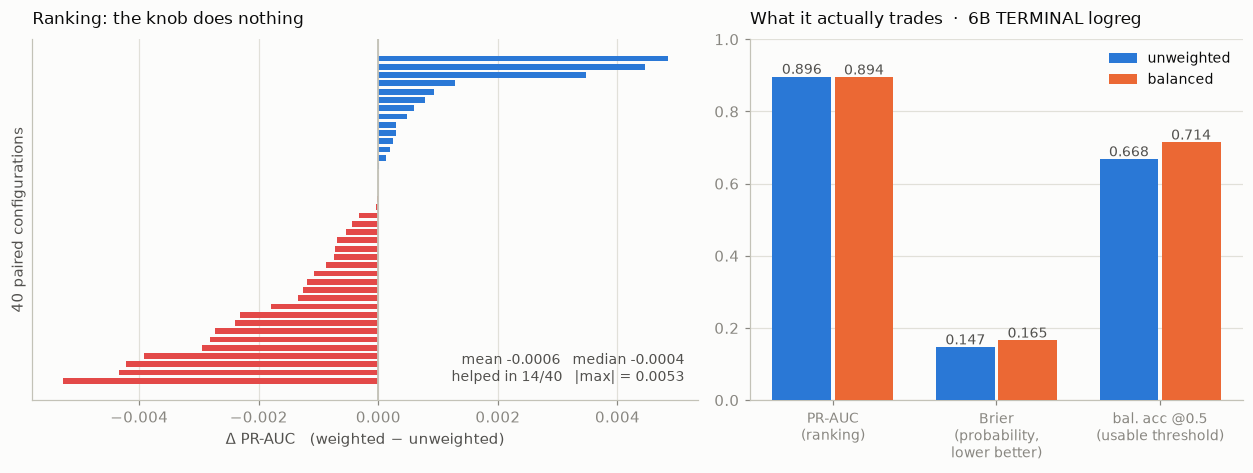

In [8]:
keys = ["task", "cell", "feature_set", "classifier"]
piv = master.pivot_table(index=keys, columns="weighted", values="pr_auc_mean").dropna()
d = (piv[True] - piv[False]).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4),
                               gridspec_kw={"width_ratios": [1.35, 1]})

ax1.barh(np.arange(len(d)), d.values, height=0.7,
         color=[BLUE if v >= 0 else RED for v in d.values], zorder=3)
ax1.axvline(0, color=AXIS, lw=1.2, zorder=4)
ax1.set_yticks([]); ax1.set_ylabel(f"{len(d)} paired configurations")
ax1.set_xlabel("Δ PR-AUC   (weighted − unweighted)")
ax1.set_title("Ranking: the knob does nothing", fontsize=11, pad=10, loc="left")
ax1.xaxis.grid(True, zorder=0); ax1.set_axisbelow(True)
ax1.text(0.98, 0.04, f"mean {d.mean():+.4f}   median {d.median():+.4f}\n"
         f"helped in {int((d>0).sum())}/{len(d)}   |max| = {d.abs().max():.4f}",
         transform=ax1.transAxes, ha="right", va="bottom", fontsize=9, color=INK2)

# the trade the knob actually makes, on the shipped cell
sel = master[(master.task == "filter") & (master.cell == "OpenCell/protein/6b") &
             (master.feature_set == "TERMINAL") & (master.classifier == "logreg")]
sel = sel.set_index("weighted")
labels = ["PR-AUC\n(ranking)", "Brier\n(probability,\nlower better)", "bal. acc @0.5\n(usable threshold)"]
cols = ["pr_auc_mean", "brier_mean", "balanced_accuracy_mean"]
x, w = np.arange(3), 0.36
for i, (wt, color, lab) in enumerate([(False, BLUE, "unweighted"), (True, ORANGE, "balanced")]):
    vals = [sel.loc[wt, c] for c in cols]
    ax2.bar(x + (i - 0.5) * (w + 0.02), vals, width=w, color=color, label=lab, zorder=3)
    for xi, v in zip(x + (i - 0.5) * (w + 0.02), vals):
        ax2.text(xi, v + 0.008, f"{v:.3f}", ha="center", fontsize=9, color=INK2)
ax2.set_xticks(x, labels, fontsize=9)
ax2.set_ylim(0, 1.0)
ax2.set_title("What it actually trades  ·  6B TERMINAL logreg", fontsize=11, pad=10, loc="left")
ax2.yaxis.grid(True, zorder=0); ax2.set_axisbelow(True)
ax2.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

**Verdict: it depends on the output, and that is a real answer, not a dodge.**

The left panel is unambiguous — across all paired configurations the ranking effect is
zero, every point inside the noise band. On the paired-evidence rule *"keep the knob only
if CV PR-AUC improves"*, the answer is **unweighted**, which is what `REPORT.md`
recommends.

The right panel shows what that rule cannot see. Weighting makes Brier **worse** and
balanced accuracy at 0.5 **better** — it buys a usable default threshold by distorting the
probability scale. So:

| If the score is for… | Setting | Why |
|---|---|---|
| **Ranking a candidate list** | `class_weight="balanced"`, ship the raw score | Only monotonic order matters; call it uncalibrated |
| **Thresholding at P > 0.5** | `None`, or wrap in `CalibratedClassifierCV` | You need the probability to mean something |

If you calibrate, **fit the calibrator on held-out folds** — calibrating on the data the
weighting already saw just re-learns the weighting.

→ **Carry forward: `balanced` for ranking, `None` + threshold from the PR curve for
probabilities.** This is the one open parameter in the final spec.

---

## Decision 7 — Is anything still on the table?

**Why ask.** Six upgrades the 80-row grid never tested. Each is re-run here under the
identical frozen folds, so the deltas are directly comparable to everything above. This is
the check against stopping early at a comfortable answer.

The cell below refits each variant — about a minute.

In [9]:
import sys, warnings
sys.path.insert(0, f"{REPO}/src/modeling")
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from data import N_FOLDS, SEED, load_table, get_folds, floor_features, load_embeddings

WIDE_C = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]     # grid searched only 1e-3..10
GRID_C = [1e-3, 1e-2, 1e-1, 1.0, 10.0]


def blocks(sub, model, names):
    index, arrays = load_embeddings(model, "protein")
    rows = np.array([index[k] for k in sub["ENSG"].values])
    return np.concatenate([arrays[b][rows] for b in names], axis=1).astype(np.float32)


def cv_per_fold(X, y, groups, fold, Cs, minority):
    """Same protocol as the grid, returning one score per fold so the result
    can be judged by the identical paired standard used above."""
    out = []
    for f in range(N_FOLDS):
        tr, te = fold != f, fold == f
        gs = GridSearchCV(
            make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=5000, class_weight="balanced",
                                             random_state=SEED)),
            {"logisticregression__C": Cs}, scoring="neg_log_loss",
            cv=StratifiedGroupKFold(3, shuffle=True, random_state=SEED), n_jobs=5)
        gs.fit(X[tr], y[tr], groups=groups[tr])
        p = gs.predict_proba(X[te])[:, 1]
        out.append(average_precision_score(1 - y[te], 1 - p) if minority
                   else average_precision_score(y[te], p))
    return np.array(out)


df = load_table()
rows = []
for task, model in [("filter", "6b"), ("terminus", "300m")]:
    sub, y, fold = get_folds(df, task)
    groups = sub["ENSG"].values
    fl, _ = floor_features(sub)
    t25 = blocks(sub, model, ["mean", "first_25", "last_25"])
    t50 = blocks(sub, model, ["mean", "first_50", "last_50"])
    minority = task == "filter"
    base = cv_per_fold(t25, y, groups, fold, GRID_C, minority)
    for name, X, Cs in [
        ("widen C grid to 1e-6",        t25,                     WIDE_C),
        ("+ FLOOR concatenated",        np.hstack([t25, fl]),    WIDE_C),
        ("50-residue windows",          t50,                     WIDE_C),
        ("25 + 50 windows together",    np.hstack([t25, t50]),   WIDE_C),
    ]:
        r = paired_stats(base, cv_per_fold(X, y, groups, fold, Cs, minority))
        rows.append(dict(task=task, variant=name, n_feat=X.shape[1],
                         delta=r["delta"], ci=r["ci"], wins=r["wins"], solid=r["solid"]))
        verdict(f"{task} · {name}", r)

head = pd.DataFrame(rows)

  SAME   filter · widen C grid to 1e-6      identical on every fold — no change at all


  NULL   filter · + FLOOR concatenated      delta=-0.0001 +/-0.0010  folds=3/5  p=0.784


  SOLID- filter · 50-residue windows        delta=-0.0147 +/-0.0136  folds=0/5  p=0.040


  SOLID- filter · 25 + 50 windows together  delta=-0.0135 +/-0.0061  folds=0/5  p=0.003


  SAME   terminus · widen C grid to 1e-6    identical on every fold — no change at all


  NULL   terminus · + FLOOR concatenated    delta=+0.0014 +/-0.0015  folds=4/5  p=0.062


  NULL   terminus · 50-residue windows      delta=-0.0104 +/-0.0124  folds=1/5  p=0.080


  NULL   terminus · 25 + 50 windows together delta=+0.0040 +/-0.0143  folds=3/5  p=0.477


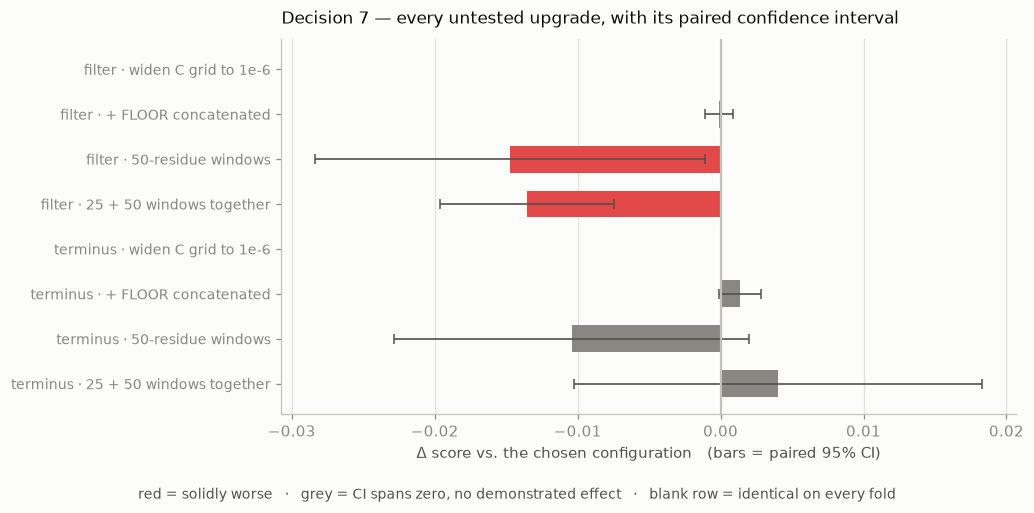

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
y = np.arange(len(head))
# colour by SIGN as everywhere else in this notebook: blue = gain, red = loss,
# grey = no demonstrated effect. A solidly harmful variant must not read as a win.
bar_colors = [(BLUE if d > 0 else RED) if ok else MUTED
              for d, ok in zip(head["delta"], head["solid"])]
ax.barh(y, head["delta"], height=0.6, color=bar_colors, zorder=3)
ax.errorbar(head["delta"], y, xerr=head["ci"], fmt="none", ecolor=INK2,
            elinewidth=1.1, capsize=3, zorder=4)
ax.axvline(0, color=AXIS, lw=1.4, zorder=5)
ax.set_yticks(y, [f"{r.task} · {r.variant}" for r in head.itertuples()], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Δ score vs. the chosen configuration   (bars = paired 95% CI)")
ax.set_title("Decision 7 — every untested upgrade, with its paired confidence interval",
             fontsize=11, pad=10, loc="left")
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
fig.text(0.5, -0.02,
         "red = solidly worse   ·   grey = CI spans zero, no demonstrated effect   "
         "·   blank row = identical on every fold",
         ha="center", va="top", fontsize=9, color=INK2)
plt.show()

**Verdict: nothing worth taking — and two variants are solidly *harmful*.**

Read the intervals, not just the bars. `50-residue windows` and `25 + 50 windows together`
both come back **SOLID negative** on `filter`: they lose in **0 of 5** folds — that is,
they are worse on every single one — at *p* = 0.040 and *p* = 0.003. Widening the terminal
window past 25 residues actively dilutes the signal for the 6B model. That is a real
finding, and it only became visible once the variants were judged fold-by-fold; the pooled
deltas alone would have looked like noise.

Two results are worth pulling out because they close off whole lines of enquiry:

- **`C = 0.001` is genuinely optimal, not an artifact of the search range.** The original
  grid searched `C ∈ [1e-3, 10]` and picked the boundary value in all 20 outer folds —
  which normally means the optimum is outside the range. Widening to `1e-6` changes
  nothing. The model really does want maximum shrinkage; the signal in 7,680 dimensions is
  that diffuse.
- **The embeddings already contain the hand-built features.** Concatenating `FLOOR` adds
  nothing, which is the same conclusion the baseline comparison in decision 1 reached from
  the opposite direction. Two independent routes to one answer.

→ **Nothing changes. The chain is complete.**

---

## The classifier

Seven decisions, each tested against a noise band derived from the data:

| # | Question | Verdict | Basis |
|---|---|---|---|
| 1 | Embeddings vs. hand features | **ESM-C** | 5/5 folds, both tasks, many × noise |
| 2 | Pooling | **TERMINAL** | solid on `terminus`, where the mechanism predicted the larger effect |
| 3 | Protein vs. construct | **protein** | null result **+** argmax is untestable |
| 4 | Model scale | **6B** | +0.05 on filter, solid via MEANPOOL, magnitude reproduced by TERMINAL |
| 5 | Classifier | **logreg** | measurement genuinely null; decided by requirement + 12× fit time |
| 6 | Class weighting | **depends on output** | ranking unaffected; probability vs. threshold trade |
| 7 | Remaining upgrades | **none** | no gains; two window variants solidly worse |

In [11]:
best = {
    "filter":   "filter|OpenCell/protein/6b|TERMINAL|logreg|w",
    "terminus": "terminus|OpenCell/protein/300m|TERMINAL|logreg|w",
}
print("FINAL CONFIGURATION")
print("  features    ESM-C 6B, bare protein, TERMINAL pooling  (mean + first_25 + last_25)")
print("  dimensions  7,680")
print("  estimator   StandardScaler -> LogisticRegression(C=0.001, max_iter=5000, seed=42)")
print("  class_weight  'balanced' for ranking | None + PR-curve threshold for probabilities")
print("  training    fit on all rows, no holdout — cross-validation is already spent")
print()
for task, cid in best.items():
    s = per_fold(cid)
    print(f"  {task:9s} {METRIC[task]:16s} {s.mean():.3f} +/- {s.std(ddof=1):.3f}   "
          f"per-fold {np.round(s, 3)}")
print()
print("  gate: proteins with a UniProt signal peptide -> terminus = 'C' before Model 2")
print("        (30/30 among successes; fires on all 55 such proteins in the 1,757-row table)")

FINAL CONFIGURATION
  features    ESM-C 6B, bare protein, TERMINAL pooling  (mean + first_25 + last_25)
  dimensions  7,680
  estimator   StandardScaler -> LogisticRegression(C=0.001, max_iter=5000, seed=42)
  class_weight  'balanced' for ranking | None + PR-curve threshold for probabilities
  training    fit on all rows, no holdout — cross-validation is already spent

  filter    minority PR-AUC  0.601 +/- 0.072   per-fold [0.64  0.58  0.679 0.489 0.616]
  terminus  PR-AUC           0.747 +/- 0.014   per-fold [0.76  0.747 0.733 0.762 0.734]

  gate: proteins with a UniProt signal peptide -> terminus = 'C' before Model 2
        (30/30 among successes; fires on all 55 such proteins in the 1,757-row table)


### What this chain cannot tell you

Three limits, none of which is a modeling problem:

1. **The negatives are confounded.** A failed knock-in can be a bad guide RNA, low
   expression, poor HDR, or a failed sort — not intrinsic un-taggability. Every score here
   is capped by that label noise, and a "false positive" is often a perfectly taggable
   protein that failed for an unrelated reason.
2. **`terminus` has no high-precision operating point.** Recall at 90% precision is
   **0.098**. It ranks; it cannot gate.
3. **Generalization beyond OpenCell is unmeasured, not disproven.** There is no external
   evaluation set in the repo.

What would move any of these is better labels, a gene tagged at *both* termini, or an
external test set — not a better classifier.